In [1]:
import os
os.environ.setdefault("DLOMIX_BACKEND", "torch")
from dlomix.models.prosit_torch import PrositIntensityUncertaintyPredictor, PrositIntensityPredictor
from dlomix.data import FragmentIonIntensityDataset
from dlomix.losses.intensity_torch import gaussian_nll, masked_spectral_distance
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import torch

Using PyTorch Backend for DLOmix. To change the backend, set the DLOMIX_BACKEND environment variable to tensorflow or pytorch and re-import DLOmix.


c:\Users\cassa\miniconda3\envs\BB200X-fixed\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Available feature extractors are (use the key of the following dict and pass it to features_to_extract in the Dataset Class):
{
   "atom_count": "Atom count of PTM.",
   "delta_mass": "Delta mass of PTM.",
   "mod_gain": "Gain of atoms due to PTM.",
   "mod_loss": "Loss of atoms due to PTM.",
   "red_smiles": "Reduced SMILES representation of PTM."
}.
When writing your own feature extractor, you can either
    (1) use the FeatureExtractor class or
    (2) write a function that can be mapped to the Hugging Face dataset.
In both cases, you can access the parsed sequence information from the dataset using the following keys, which all provide python lists:
    - _parsed_sequence: parsed sequence
    - _n_term_mods: N-terminal modifications
    - _c_term_mods: C-terminal modifications



## Loading Data

In [2]:
# Dummy exammle
# first the m/z value needs to be calculated.
residue_masses = {
    "G":57.02146, "A":71.03711, "S":87.03203,
    "P":97.05276, "V":99.06841, "T":101.04768,
    "C":103.00919, "L":113.08406, "I":113.08406,
    "N":114.04293, "D":115.02694, "Q":128.05858,
    "K":128.09496, "E":129.04259, "M":131.04049,
    "H":137.05891, "F":147.06841, "R":156.10111,
    "Y":163.06333, "W":186.07931,
    "Water":18.010565, "Proton":1.007276
}

y_ion_mz_label =[
    "y1 +1", "y1 +2", "y1 +3", "y2 +1", "y2 +2", "y2 +3", 
    "y3 +1", "y3 +2", "y3 +3", "y4 +1", "y4 +2", "y4 +3", 
    "y5 +1", "y5 +2", "y5 +3", "y6 +1", "y6 +2", "y6 +3", 
    "y7 +1", "y7 +2", "y7 +3", "y8 +1", "y8 +2", "y8 +3", 
    "y9 +1", "y9 +2", "y9 +3", "y10 +1", "y10 +2", "y10 +3",   
    "y11 +1", "y11 +2", "y11 +3", "y12 +1", "y12 +2", "y12 +3",   
    "y13 +1", "y13 +2", "y13 +3", "y14 +1", "y14 +2", "y14 +3",   
    "y15 +1", "y15 +2", "y15 +3", "y16 +1", "y16 +2", "y16 +3",   
    "y17 +1", "y17 +2", "y17 +3", "y18 +1", "y18 +2", "y18 +3",   
    "y19 +1", "y19 +2", "y19 +3", "y20 +1", "y20 +2", "y20 +3",   
    "y21 +1", "y21 +2", "y21 +3", "y22 +1", "y22 +2", "y22 +3",   
    "y23 +1", "y23 +2", "y23 +3", "y24 +1", "y24 +2", "y24 +3",   
    "y25 +1", "y25 +2", "y25 +3", "y26 +1", "y26 +2", "y26 +3",   
    "y27 +1", "y27 +2", "y27 +3", "y28 +1", "y28 +2", "y28 +3",   
    "y29 +1", "y29 +2", "y29 +3", "y30 +1", "y30 +2", "y30 +3",   
]

b_ion_mz_label = [
    "b1 +1", "b1 +2", "b1 +3", "b2 +1", "b2 +2", "b2 +3",
    "b3 +1", "b3 +2", "b3 +3", "b4 +1", "b4 +2", "b4 +3",
    "b5 +1", "b5 +2", "b5 +3", "b6 +1", "b6 +2", "b6 +3",
    "b7 +1", "b7 +2", "b7 +3", "b8 +1", "b8 +2", "b8 +3",
    "b9 +1", "b9 +2", "b9 +3", "b10 +1", "b10 +2", "b10 +3",
    "b11 +1", "b11 +2", "b11 +3", "b12 +1", "b12 +2", "b12 +3",
    "b13 +1", "b13 +2", "b13 +3", "b14 +1", "b14 +2", "b14 +3",
    "b15 +1", "b15 +2", "b15 +3", "b16 +1", "b16 +2", "b16 +3",
    "b17 +1", "b17 +2", "b17 +3", "b18 +1", "b18 +2", "b18 +3",
    "b19 +1", "b19 +2", "b19 +3", "b20 +1", "b20 +2", "b20 +3",
    "b21 +1", "b21 +2", "b21 +3", "b22 +1", "b22 +2", "b22 +3",
    "b23 +1", "b23 +2", "b23 +3", "b24 +1", "b24 +2", "b24 +3",
    "b25 +1", "b25 +2", "b25 +3", "b26 +1", "b26 +2", "b26 +3",
    "b27 +1", "b27 +2", "b27 +3", "b28 +1", "b28 +2", "b28 +3",
    "b29 +1", "b29 +2", "b29 +3", "b30 +1", "b30 +2", "b30 +3",
]

alphabet = {
    'A': 1, 'C': 2, 'D': 3, 'E': 4, 
    'F': 5, 'G': 6, 'H': 7, 'I': 8, 
    'K': 9, 'L': 10, 'M': 11, 'N': 12, 
    'P': 13, 'Q': 14, 'R': 15, 'S': 16, 
    'T': 17, 'V': 18, 'W': 19, 'Y': 20,
    }

In [3]:
def fragment_ions(sequence:str, verbose=False):
    '''
    Returns the b-, and y-ion masses of the given sequence,\n
    verbose will print results after each step.
    '''
    masses = np.array([residue_masses[aa] for aa in sequence])
    flip_masses = np.flip(masses)
    b_cumsum = np.cumsum(masses[:-1])
    y_cumsum = np.cumsum(flip_masses[:-1])
    
    b_ions_masses = b_cumsum + residue_masses["Proton"]
    b_ions_labels = np.array([(f'B{n}: ' + sequence[:n]) for n in range(1, len(sequence))])
    
    y_ions_masses = y_cumsum + (residue_masses["Proton"] + residue_masses["Water"])
    y_ions_labels = np.flip(np.array([(f'Y{len(sequence)-n}: ' + sequence[n:]) for n in range(1, len(sequence))]))

    if verbose:
        print(f"Residue masses: {masses}")
        print(f"b-ion only aa masses: {b_cumsum}")
        print(f"y-ion only aa masses: {y_cumsum}\n")
        print(f"b-ion sequences: {b_ions_labels}")
        print(f"b-ion masses: {b_ions_masses}\n")
        print(f"y-ion sequences: {y_ions_labels}")
        print(f"y-ion masses: {y_ions_masses}")
        
    return b_ions_masses, b_ions_labels, y_ions_masses, y_ions_labels

def mz(b_ions, y_ions, n_charge, verbose=False):
    '''
    Creates a number_of_charges x number_of_ions numpy array of m/z values,\n
    verbose will print the numpy arrays, rows start from +1 and goes to n_charge
    '''
    b_mz = np.zeros(shape=(n_charge, len(b_ions)))
    y_mz = np.zeros(shape=(n_charge, len(y_ions)))
    
    for c in range(1, n_charge+1):
        b_mass_charge = b_ions / c
        y_mass_charge = y_ions / c
        b_mz[c-1] = b_mass_charge
        y_mz[c-1] = y_mass_charge
    if verbose:
        print(b_mz)
        print(y_mz)
    return b_mz, y_mz

def encode_sequence(sequence, seq_length):
    encoding = [21,] # N-terminal
    for aa in sequence:
        encoding.append(alphabet[aa])
    encoding.append(22) # C-terminal
    #padding
    diff = seq_length - len(sequence)
    for n in range(0, diff):
        encoding.append(0)
    print(f"Encoding: {encoding}\nLength: {len(encoding)}")
    return encoding

In [4]:
sequence = "TRLQAENSELSR"
save = encode_sequence(sequence, 30) # Will be 2 elements longer since it adds an n and c terminal

# Example peptide (should be fetched from test set)
sequence = "TRLQAENSELSR"

encoded_sequence = [encode_sequence(sequence, 30)]
intensity_raw = [[ 0.1000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.3400,  0.0000,
         0.0000,  0.1300,  0.0000,  0.0000,  1.0000,  0.0200,  0.0000,  0.0900,
         0.0000,  0.0000,  0.5500,  0.0000,  0.0000,  0.6300,  0.1500,  0.0000,
         0.7400,  0.0900,  0.0000,  0.7800,  0.1600,  0.0000,  0.9000,  0.0500,
         0.0000,  0.6500,  0.1500,  0.0000,  0.1000,  0.0100,  0.0000,  0.2600,
         0.0600,  0.0000,  0.0500,  0.0000,  0.0000,  0.0800,  0.1600,  0.0000,
         0.0000,  0.0000,  0.0200,  0.0500,  0.0100,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000]]
collision_energy_normed = [0.2556]
precursor_charge_onehot = [[0., 0., 1., 0., 0., 0.]] # +3
mod_loss = [[[1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.],
            [1., 1., 1., 1., 1., 1.], [1., 1., 1., 1., 1., 1.]]]
delta_mass = [[[0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.], [0.], [0.], [0.], [0.],
              [0.], [0.]]]

test_data = {
    'modified_sequence': torch.tensor(encoded_sequence),
    #'intensities_raw': torch.tensor(intensity_raw),
    'collision_energy_aligned_normed': torch.tensor(collision_energy_normed),
    'precursor_charge_onehot': torch.tensor(precursor_charge_onehot),
    'mod_loss': torch.tensor(mod_loss),
    'delta_mass': torch.tensor(delta_mass),
}

b_ion_mass, b_labl, y_ion_mass, y_labl = fragment_ions(sequence)
b_mz, y_mz = mz(b_ion_mass, y_ion_mass, 3)

Encoding: [21, 17, 15, 10, 14, 1, 4, 12, 16, 4, 10, 16, 15, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32
Encoding: [21, 17, 15, 10, 14, 1, 4, 12, 16, 4, 10, 16, 15, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 32


In [5]:
# Getting dataset
TRAIN_DATAPATH = "../../example_dataset/intensity/third_pool_processed_sample.parquet" # RELATIVE PATH needs to be changed should the file move location

d = FragmentIonIntensityDataset(
    data_source=TRAIN_DATAPATH,
    #data_source=TRAIN_DATAPATH,
    #val_data_source=VAL_DATAPATH,
    #test_data_source=TEST_DATAPATH,
    max_seq_len=32,
    batch_size=8,
    val_ratio=0.2,
    model_features=["collision_energy_aligned_normed", "precursor_charge_onehot"],
    sequence_column="modified_sequence",
    label_column="intensities_raw",
    features_to_extract=["mod_loss", "delta_mass"],
    dataset_type="pt",
    with_termini=True,
    encoding_scheme="naive-mods", # Was missing in original code, setting encoding scheme to naive-mods is what allows modifications to exist (default is Un-modified (UNMOD))
)


C:\Users\cassa\GitRepos\dlomix\src\dlomix\data\processing\processors.py:303: UserWarning: The unknown token index '1' is already used in the provided alphabet. It will be reassigned to index 23.
  warnings.warn(
C:\Users\cassa\GitRepos\dlomix\src\dlomix\data\processing\processors.py:309: UserWarning: The unknown token 'X' is not present in the provided alphabet. It will be added with index 23.
  warnings.warn(
Casting the dataset: 100%|██████████| 200/200 [00:00<00:00, 9448.55 examples/s]


## Uncertainty Aware Training and Data Formatting

In [6]:
sequence_length = 32
model = PrositIntensityUncertaintyPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001)
loss_criterion = gaussian_nll

for epoch in tqdm(range(0, 20)):
    epoch_loss = 0
    mae = 0
    v_mae = 0
    model.train()
    data_size = len(d.tensor_train_data)
    for batch in d.tensor_train_data:
        optimizer.zero_grad()

        output_mean, output_var, output_presence = model(batch)
        loss = loss_criterion(batch["intensities_raw"], output_mean, output_var, output_presence, batch["modified_sequence"])
        
        # print(loss.item())
        y_true = batch["intensities_raw"].detach()
        present = y_true > 0
        y_true[~present] = 0
        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()

        epoch_loss += loss.item()

        loss.backward()

        # Add before optimizer.step()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
        )
        optimizer.step()
    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")

    model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        val_data_size = len(d.tensor_val_data)
        for batch in d.tensor_val_data:
            
            val_mean, val_var, val_missing = model(batch)
            val_loss = loss_criterion(batch["intensities_raw"], val_mean, val_var, val_missing, batch["modified_sequence"])
            val_loss_total += val_loss.item()

            y_true = batch["intensities_raw"].detach()
            present = y_true > 0
            y_true[~present] = 0
            v_mae += torch.mean(torch.abs(torch.sub(val_mean, y_true))).item()

        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 Summary: Training Loss: 1.5979
Training Mean Absolute Error: 0.3743


  5%|▌         | 1/20 [00:15<04:51, 15.33s/it]

Validation Loss: 1.1306
Validation Mean Absolute Error: 0.9690
Epoch 1 Summary: Training Loss: 1.0816
Training Mean Absolute Error: 1.5260


 10%|█         | 2/20 [00:30<04:36, 15.36s/it]

...

Validation Loss: 0.8860
Validation Mean Absolute Error: 2.7274
Epoch 18 Summary: Training Loss: 0.9106
Training Mean Absolute Error: 2.7543


 95%|█████████▌| 19/20 [04:35<00:14, 14.38s/it]

Validation Loss: 0.8843
Validation Mean Absolute Error: 2.7337
Epoch 19 Summary: Training Loss: 0.9092
Training Mean Absolute Error: 2.7567


100%|██████████| 20/20 [04:51<00:00, 14.56s/it]

Validation Loss: 0.8826
Validation Mean Absolute Error: 2.7343


In [7]:
model.eval()
log_mean, log_var, presence = model(test_data)

#  Data formatting before plotting
np_mean = torch.exp(log_mean.detach().float())
np_mean = np_mean.cpu().numpy().flatten() 

np_var = torch.exp(log_var.detach().float())
np_var = np_var.cpu().numpy().flatten() # Numpy turns positive small tensor values negative

np_presence = torch.sigmoid(presence.detach()).numpy().flatten()

np_true = torch.tensor(intensity_raw).detach()
present = np_true > 0
np_true[~present] = 0
np_true = np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
np_mean = np_mean[:possible_indx]
np_var = np_var[:possible_indx]
np_presence = np_presence[:possible_indx]
np_true = np_true[:possible_indx]

# Shorten all variances that would go beyond 0 in the plot
np_var_lower = np_var
for e in range(0, len(np_mean)-1):
    if np_mean[e] < np_var_lower[e]:
        np_var_lower[e] = np_mean[e]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_ions_mean = np_mean[::6]
y2_ions_mean = np_mean[1::6]
y3_ions_mean = np_mean[2::6]
b1_ions_mean = np_mean[3::6]
b2_ions_mean = np_mean[4::6]
b3_ions_mean = np_mean[5::6]

y1_ions_var = np_var[::6]
y2_ions_var = np_var[1::6]
y3_ions_var = np_var[2::6]
b1_ions_var = np_var[3::6]
b2_ions_var = np_var[4::6]
b3_ions_var = np_var[5::6]

print(b1_ions_var)

y1_ions_var_lower = np_var_lower[::6]
y2_ions_var_lower = np_var_lower[1::6]
y3_ions_var_lower = np_var_lower[2::6]
b1_ions_var_lower = np_var_lower[3::6]
b2_ions_var_lower = np_var_lower[4::6]
b3_ions_var_lower = np_var_lower[5::6]

print(b1_ions_var_lower)

y1_ions_presence = np_presence[::6]
y2_ions_presence = np_presence[1::6]
y3_ions_presence = np_presence[2::6]
b1_ions_presence = np_presence[3::6]
b2_ions_presence = np_presence[4::6]
b3_ions_presence = np_presence[5::6]

y1_ions_true = np_true[::6]
y2_ions_true = np_true[1::6]
y3_ions_true = np_true[2::6]
b1_ions_true = np_true[3::6]
b2_ions_true = np_true[4::6]
b3_ions_true = np_true[5::6]

# Create vector with all y ions and one with all b ions
# y_ions_mean = np.array([y_p1_mean, y_p2_mean, y_p3_mean]).flatten()
# y_ions_var = np.array([y_p1_var, y_p2_var, y_p3_var]).flatten()
# y_ions_presence = np.array([y_p1_presence, y_p2_presence, y_p3_presence]).flatten()

# b_ions_mean = np.array([b_p1_mean, b_p2_mean, b_p3_mean]).flatten()
# b_ions_var = np.array([b_p1_var, b_p2_var, b_p3_var]).flatten()
# b_ions_presence = np.array([b_p1_presence, b_p2_presence, b_p3_presence]).flatten()

# Get labels for peaks (full ion sequences are in b_labl and y_labl)
y1_point_labl = y_ion_mz_label[:(3*(len(sequence)-1)):3]
y2_point_labl = y_ion_mz_label[1:(3*(len(sequence)-1)):3]
y3_point_labl = y_ion_mz_label[2:(3*(len(sequence)-1)):3]

b1_point_labl = b_ion_mz_label[:(3*(len(sequence)-1)):3]
b2_point_labl = b_ion_mz_label[1:(3*(len(sequence)-1)):3]
b3_point_labl = b_ion_mz_label[2:(3*(len(sequence)-1)):3]

# Will now have the same order as the mean, var, and presence arrays
# y_point_labl = np.array([y1_point_labl, y2_point_labl, y3_point_labl]).flatten()
# b_point_labl = np.array([b1_point_labl, b2_point_labl, b3_point_labl]).flatten()

# Get the mz values for each ion type (x-axis), will be same structure as arrays created above
y1_mz = y_mz[0]
y2_mz = y_mz[1]
y3_mz = y_mz[2]

b1_mz = b_mz[0]
b2_mz = b_mz[1]
b3_mz = b_mz[2]

Possible states: 66
[0.23919146 0.1388246  0.08899699 0.08487578 0.08338612 0.07407739
 0.0672787  0.07963603 0.09050226 0.05326393 0.05358283]
[0.23919146 0.1388246  0.08899699 0.08487578 0.08338612 0.07407739
 0.0672787  0.07963603 0.09050226 0.05326393 0.05358283]


In [8]:
print(b1_mz)
print(b1_ions_true)

[ 102.054956  258.156066  371.240126  499.298706  570.335816  699.378406
  813.421336  900.453366 1029.495956 1142.580016 1229.612046]
[0.   0.13 0.09 0.63 0.78 0.65 0.26 0.08 0.05 0.   0.  ]


## Masked Spectral Distance Training and formating

In [9]:
sequence_length = 32
MSD_model = PrositIntensityPredictor(
    seq_length=sequence_length,
        use_prosit_ptm_features=True,
        input_keys={
            "SEQUENCE_KEY": "modified_sequence",
        },
        meta_data_keys={
            "COLLISION_ENERGY_KEY": "collision_energy_aligned_normed",
            "PRECURSOR_CHARGE_KEY": "precursor_charge_onehot",
        },
        with_termini=True,
)

optimizer = torch.optim.Adam(params=MSD_model.parameters(), lr=0.0001)
loss_criterion = masked_spectral_distance

for epoch in tqdm(range(0, 20)):
    epoch_loss = 0
    mae = 0
    v_mae = 0
    MSD_model.train()
    data_size = len(d.tensor_train_data)
    for batch in d.tensor_train_data:
        optimizer.zero_grad()

        output = MSD_model(batch)
        loss = loss_criterion(batch["intensities_raw"], output)
        
        # print(loss.item())
        y_true = batch["intensities_raw"].detach()
        present = y_true > 0
        y_true[~present] = 0
        mae += torch.mean(torch.abs(torch.sub(output_mean, y_true))).item()

        epoch_loss += loss.item()

        loss.backward()

        # Add before optimizer.step()
        torch.nn.utils.clip_grad_norm_(
            MSD_model.parameters(), max_norm=1, norm_type=2, error_if_nonfinite=False
        )
        optimizer.step()
    print(f"Epoch {epoch} Summary: Training Loss: {epoch_loss / data_size:.4f}")
    print(f"Training Mean Absolute Error: {mae / data_size:.4f}")

    MSD_model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        val_data_size = len(d.tensor_val_data)
        for batch in d.tensor_val_data:
            
            val = MSD_model(batch)
            val_loss = loss_criterion(batch["intensities_raw"], val)
            val_loss_total += val_loss.item()

            y_true = batch["intensities_raw"].detach()
            present = y_true > 0
            y_true[~present] = 0
            v_mae += torch.mean(torch.abs(torch.sub(val, y_true))).item()

        print(f"Validation Loss: {val_loss_total / val_data_size:.4f}")
        print(f"Validation Mean Absolute Error: {v_mae / val_data_size:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 Summary: Training Loss: 0.7168
Training Mean Absolute Error: 2.7461


  5%|▌         | 1/20 [00:12<04:05, 12.94s/it]

Validation Loss: 0.6532
Validation Mean Absolute Error: 0.0321
Epoch 1 Summary: Training Loss: 0.6534
Training Mean Absolute Error: 2.7461


 10%|█         | 2/20 [00:25<03:49, 12.77s/it]

...

Validation Loss: 0.5776
Validation Mean Absolute Error: 0.0328
Epoch 18 Summary: Training Loss: 0.5853
Training Mean Absolute Error: 2.7461


 95%|█████████▌| 19/20 [04:02<00:12, 12.78s/it]

Validation Loss: 0.5782
Validation Mean Absolute Error: 0.0326
Epoch 19 Summary: Training Loss: 0.5807
Training Mean Absolute Error: 2.7461


100%|██████████| 20/20 [04:15<00:00, 12.76s/it]

Validation Loss: 0.5753
Validation Mean Absolute Error: 0.0323


In [10]:
MSD_model.eval()
MSD_mean = MSD_model(test_data)

# Data formatting before plotting
MSD_np_mean = MSD_mean.detach()
negative = MSD_np_mean < 0
MSD_np_mean[negative] = 0
MSD_np_mean = MSD_np_mean.cpu().numpy().flatten() 

MSD_np_true = torch.tensor(intensity_raw).detach()
present = MSD_np_true > 0
MSD_np_true[~present] = 0
MSD_np_true = MSD_np_true.cpu().numpy().flatten()

# Remove the impossible predictions (everything above the sequence length)
possible_indx = (len(sequence) - 1) * 3 * 2
print(f"Possible states: {possible_indx}")
MSD_np_mean = MSD_np_mean[:possible_indx]
MSD_np_true = MSD_np_true[:possible_indx]

# Output tensor is in order y1 +1, y1 +2, y1 +3, b1 +1, b1 +2, b1 +3 ....
# Need to seperate y and b
# Every 6th element is increasing ion number with same charge
y1_MSD_ions_mean = MSD_np_mean[::6]
y2_MSD_ions_mean = MSD_np_mean[1::6]
y3_MSD_ions_mean = MSD_np_mean[2::6]
b1_MSD_ions_mean = MSD_np_mean[3::6]
b2_MSD_ions_mean = MSD_np_mean[4::6]
b3_MSD_ions_mean = MSD_np_mean[5::6]

y1_MSD_ions_true = MSD_np_true[::6]
y2_MSD_ions_true = MSD_np_true[1::6]
y3_MSD_ions_true = MSD_np_true[2::6]
b1_MSD_ions_true = MSD_np_true[3::6]
b2_MSD_ions_true = MSD_np_true[4::6]
b3_MSD_ions_true = MSD_np_true[5::6]

print(b1_MSD_ions_mean)

Possible states: 66
[0.01020622 0.05534485 0.0323125  0.02970511 0.02399665 0.02517615
 0.0264941  0.01282576 0.         0.         0.        ]


## Plotting

### True Intensities

C:\Users\cassa\AppData\Local\Temp\ipykernel_16944\2488780738.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


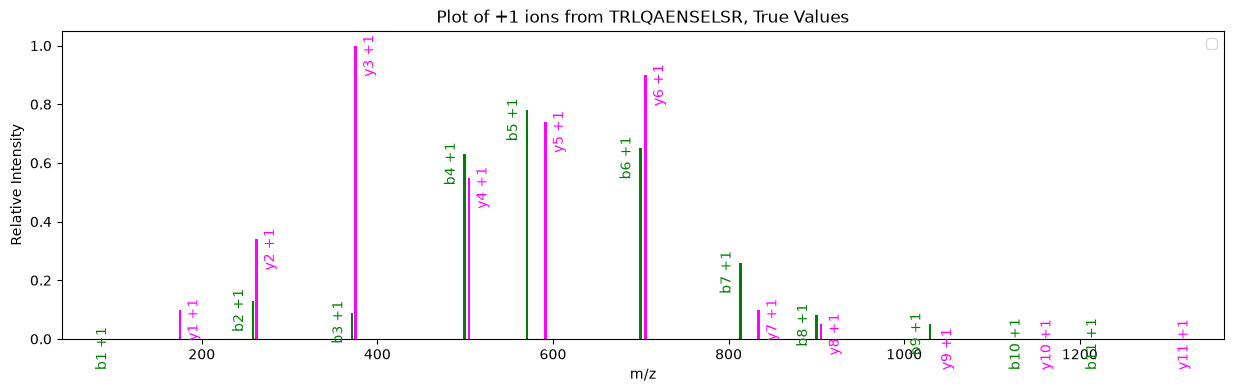

In [11]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, True Values')

plt.bar(b1_mz, b1_ions_true, width=3, color='g')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='magenta')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.legend()

### Uncertainty Aware Model With Labels

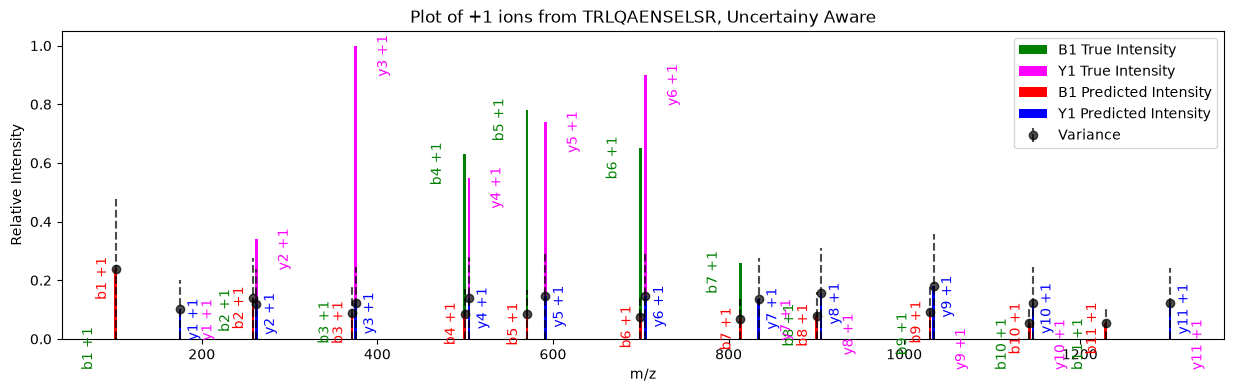

In [12]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Uncertainy Aware')

plt.bar(b1_mz, b1_ions_true, width=3, color='g', label='B1 True Intensity')
for xi, yi, text, in zip(b1_mz, b1_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-25, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_ions_true, width=3, color='magenta', label='Y1 True Intensity')
for xi, yi, text, in zip(y1_mz, y1_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.bar(b1_mz, b1_ions_mean, width=3, color='r', label='B1 Predicted Intensity')
eb_b = plt.errorbar(b1_mz, b1_ions_mean, yerr=[b1_ions_var_lower, b1_ions_var], color='black', fmt='o', alpha=0.7)
eb_b[-1][0].set_linestyle('--')
for xi, yi, text, in zip(b1_mz, b1_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
eb_y = plt.errorbar(y1_mz, y1_ions_mean, yerr=[y1_ions_var_lower, y1_ions_var], color='black', fmt='o', alpha=0.7, label='Variance')
eb_y[-1][0].set_linestyle('--')
for xi, yi, text, in zip(y1_mz, y1_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()

### Uncertainty Aware Model With Presence Prediction

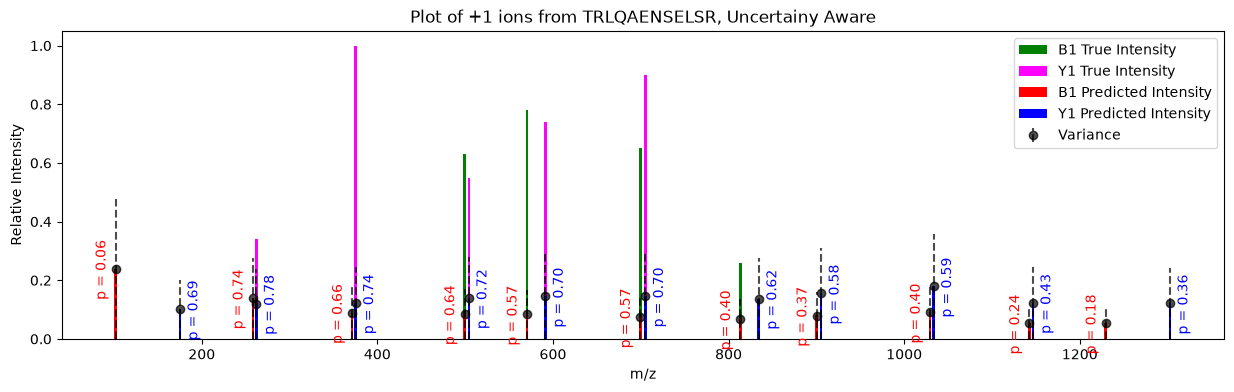

In [13]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Uncertainy Aware')

plt.bar(b1_mz, b1_ions_true, width=3, color='g', label='B1 True Intensity')
plt.bar(y1_mz, y1_ions_true, width=3, color='magenta', label='Y1 True Intensity')


plt.bar(b1_mz, b1_ions_mean, width=3, color='r', label='B1 Predicted Intensity')
eb_b = plt.errorbar(b1_mz, b1_ions_mean, yerr=[b1_ions_var_lower, b1_ions_var], color='black', fmt='o', alpha=0.7)
eb_b[-1][0].set_linestyle('--')
for xi, yi, presence, in zip(b1_mz, b1_ions_mean, b1_ions_presence):
    text = f"p = {presence:.2f}"
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
eb_y = plt.errorbar(y1_mz, y1_ions_mean, yerr=[y1_ions_var_lower, y1_ions_var], color='black', fmt='o', alpha=0.7, label='Variance')
eb_y[-1][0].set_linestyle('--')
for xi, yi, presence, in zip(y1_mz, y1_ions_mean, y1_ions_presence):
    text = f"p = {presence:.2f}"
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()

### Standard Prosit Model

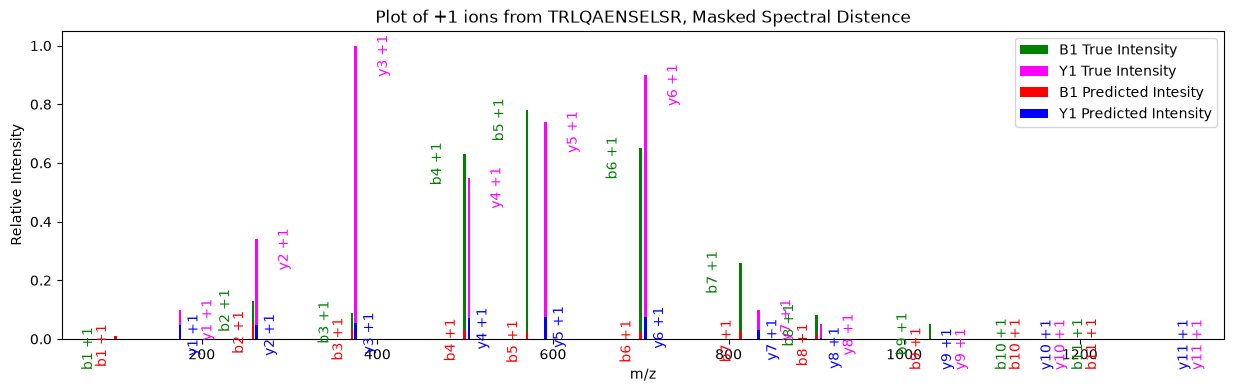

: 

In [ ]:
fig, ax = plt.subplots(figsize=(15,4))

plt.xlabel('m/z')
plt.ylabel('Relative Intensity')
plt.title(f'Plot of +1 ions from {sequence}, Masked Spectral Distence')

plt.bar(b1_mz, b1_MSD_ions_true, width=3, color='g', label='B1 True Intensity')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_true, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-25, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'g'
    )

plt.bar(y1_mz, y1_MSD_ions_true, width=3, color='magenta', label='Y1 True Intensity')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_true, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'magenta'
    )

plt.bar(b1_mz, b1_MSD_ions_mean, width=3, color='r', label='B1 Predicted Intesity')
for xi, yi, text, in zip(b1_mz, b1_MSD_ions_mean, b1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (-15, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'r'
    )

plt.bar(y1_mz, y1_MSD_ions_mean, width=3, color='b', label='Y1 Predicted Intensity')
for xi, yi, text, in zip(y1_mz, y1_MSD_ions_mean, y1_point_labl):
    ax.annotate(
        text,
        xy = (xi, yi), xycoords='data',
        xytext = (5, -20), textcoords = 'offset points',
        rotation = 'vertical', color = 'b'
    )

plt.legend()
#plt.bar(y_mz, y_MSD_ions_mean, color='b')